# Load Packages and Data

In [1]:
import importlib
import pitch_suggestions

importlib.reload(pitch_suggestions)

<module 'pitch_suggestions' from '/Users/kids/Pitcher Similarity/pitch_suggestions.py'>

In [2]:
from data import build_all
from pitch_suggestions import suggest_pitches, plot_pitch_clusters
from pitch_suggestions import _find_target, _find_biomech_comps, _collect_pitches, _tag_novelty, _cluster_novel
import warnings
import pandas as pd

from biomech import compute_euclidean_distances

pd.set_option('display.max_columns', None)

warnings.filterwarnings("ignore")

In [3]:
data = build_all(live=False)

statcast_clean  = data['statcast_clean']
pitch_type_summ = data['pitch_type_summ']
pitcher_summ    = data['pitcher_summ']
pitcher_summ_r  = data['pitcher_summ_r']
pitcher_summ_l  = data['pitcher_summ_l']
pitch_type_r  = data['pitch_type_r']
pitch_type_l  = data['pitch_type_l']

statcast_clean_25 = statcast_clean[statcast_clean['game_year'] == 2025]

def pid(name, pool):
    """Resolve a player name to its unique pitcher id within a pitcher_summ pool."""
    ids = pool.loc[pool['player_name'] == name, 'pitcher'].unique()
    if len(ids) != 1:
        raise ValueError(f"{name!r} maps to {len(ids)} pitcher ids: {sorted(ids)}")
    return int(ids[0])


# Identify Pitch Opportunities

In [4]:
BIOMECH_FEATURES    = ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball']
PITCH_CHAR_FEATURES = ['release_speed', 'pfx_x', 'pfx_z']

### Bello Example

Example of what the tool recommends

In [5]:
b_bello = suggest_pitches(
    target_pitcher_id=pid('Bello, Brayan', pitcher_summ_r),
    pitcher_summ=pitcher_summ_r,
    pitch_type_summ=pitch_type_r,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [6]:
b_bello['status']

'ok'

In [7]:
b_bello['target_info']

pitcher                        678394
p_throws                            R
player_name             Bello, Brayan
game_year                        2026
release_pos_x               -1.690124
release_pos_z                5.654823
release_extension            6.205062
arm_angle                   40.191786
n                                1047
max_velo                    94.829571
max_spin                  2438.546875
pri_fb                             SI
fb_pfx_x                    -1.366907
fb_n                            443.0
pri_fb_cd                           0
active_spin_fastball             82.5
FB_type                            FF
Name: 3452, dtype: object

In [8]:
b_bello['comps'].sort_values('comp_pitcher')[20:25]

,comp_pitcher,comp_year,distance
173,519076,2021,1.084471
176,519151,2022,1.087357
46,519326,2021,0.688577
141,541640,2022,1.009698
245,542585,2023,1.237453


In [9]:
print(b_bello['comp_pitches'].shape)
b_bello['comp_pitches'].head()

(119, 20)


,pitcher,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_dist_to_centroid,_cluster_median_dist,_cluster_mad,_outlier_threshold,cluster_label,biomech_distance,sim_weight
0,429722,"Santana, Ervin",2021,CH,87.180000,-0.666571,1.075429,35,1063,0.032926,1.207707,CH,1,0.758426,1.274132,0.293405,2.154346,CH,0.843999,1.184834
1,605541,"Wright Jr., Mike",2021,CH,77.033333,-1.362333,0.285000,30,325,0.092308,1.936090,CH,1,1.843121,1.274132,0.293405,2.154346,CH,1.433731,0.697480
2,641585,"France, J.P.",2024,CH,82.346226,-1.249811,0.944811,106,466,0.227468,1.236508,CH,1,1.115633,1.274132,0.293405,2.154346,CH,1.185428,0.843577
3,643615,"Zeuch, T.J.",2021,CH,81.695238,-1.075714,0.760952,21,286,0.073427,1.253053,CH,1,0.948871,1.274132,0.293405,2.154346,CH,0.884609,1.130441
4,647336,"Soroka, Michael",2023,CH,82.030612,-1.304184,1.149694,98,537,0.182495,1.453968,CH,1,1.264254,1.274132,0.293405,2.154346,CH,0.798380,1.252535


In [10]:
b_bello['suggestions']

,cluster_label,cluster,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,pitch_types_in_cluster,comp_pitchers
0,Curveball*,0,91,79.1,1.12,-0.67,1.48,79.2,1.12,-0.71,"Slow Curve, Curveball, Knuckle Curve, Slider, ...","Adam, Jason, Almonte, Yency, Anderson, Drew, A..."
1,Changeup*,1,17,83.9,-0.34,0.83,1.41,83.9,-0.30,0.79,"Changeup, Cutter, Other, Sweeper","Armstrong, Shawn, Bibee, Tanner, Cease, Dylan,..."


In [11]:
b_bello['target_pitches']

,pitcher,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n
0,678394,"Bello, Brayan",2026,CH,88.442077,-1.357978,0.470164,183
1,678394,"Bello, Brayan",2026,CU,83.440625,0.148281,-0.691406,64
2,678394,"Bello, Brayan",2026,FC,87.159036,-0.013373,0.207590,166
3,678394,"Bello, Brayan",2026,FF,94.598462,-0.558923,0.934154,65
4,678394,"Bello, Brayan",2026,SI,94.829571,-1.366907,0.516005,443
5,678394,"Bello, Brayan",2026,ST,85.747619,0.609921,-0.311905,126


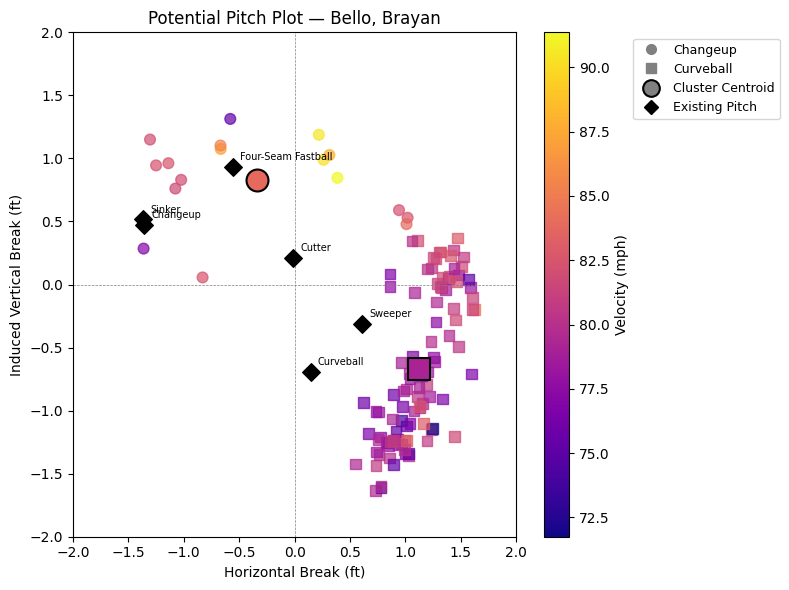

In [12]:
plot_pitch_clusters(b_bello)

In [13]:
b_bello['comp_pitches'].sort_values('_dist_to_centroid', ascending=False)

,pitcher,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_dist_to_centroid,_cluster_median_dist,_cluster_mad,_outlier_threshold,cluster_label,biomech_distance,sim_weight
1,605541,"Wright Jr., Mike",2021,CH,77.033333,-1.362333,0.285000,30,325,0.092308,1.936090,CH,1,1.843121,1.274132,0.293405,2.154346,CH,1.433731,0.697480
106,668820,"Kranick, Max",2025,ST,82.514634,1.019512,0.529756,41,529,0.077505,1.407966,ST,1,1.670259,1.274132,0.293405,2.154346,CH,1.373865,0.727873
110,676604,"Zuber, Tyler",2025,ST,82.820238,1.470714,0.369881,84,245,0.342857,1.490498,ST,0,1.666914,0.945311,0.263761,1.736595,CU,0.887444,1.126830
5,656302,"Cease, Dylan",2023,CH,75.051087,-0.580217,1.313370,92,3255,0.028264,2.664292,FC,1,1.665275,1.274132,0.293405,2.154346,CH,1.360733,0.734898
112,681806,"Wantz, Andrew",2023,ST,83.784971,1.009769,0.479017,173,658,0.262918,1.270754,ST,1,1.663523,1.274132,0.293405,2.154346,CH,0.415464,2.406940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,661269,"Gutierrez, Vladimir",2022,CU,78.413483,1.259326,-0.612472,89,684,0.130117,1.512854,ST,0,0.218322,0.945311,0.263761,1.736595,CU,1.383676,0.722712
79,672456,"Montero, Keider",2025,KC,79.006075,1.121822,-0.818411,214,1473,0.145282,1.378229,CU,0,0.211286,0.945311,0.263761,1.736595,CU,0.609194,1.641512
28,621107,"Eflin, Zach",2023,CU,79.053756,0.959028,-0.619352,679,2577,0.263485,1.209738,CU,0,0.207874,0.945311,0.263761,1.736595,CU,1.442939,0.693030
40,663562,"Davis, Noah",2023,CU,78.435556,1.201778,-0.694444,45,601,0.074875,1.497569,CU,0,0.153403,0.945311,0.263761,1.736595,CU,1.453018,0.688222


### Step Guide

In [14]:
target_row, target_year = _find_target(pitcher_summ_l, pid('Beeks, Jalen', pitcher_summ_l))

In [15]:
target_dists = _find_biomech_comps(
    pitcher_summ_l, pid('Beeks, Jalen', pitcher_summ_l), target_year,
    BIOMECH_FEATURES, biomech_distance_threshold=1.5, min_pitches=20,
)

In [16]:
target_pitches, comp_pitches = _collect_pitches(
    pitch_type_l, target_pitcher_id=pid('Beeks, Jalen', pitcher_summ_l), target_year=target_year, target_dists=target_dists,
    pitch_features=PITCH_CHAR_FEATURES, min_comp_usage_pct=0.01, min_pitches=20
)

In [17]:
from sklearn.preprocessing import StandardScaler
global_scaler = StandardScaler().fit(
    pitch_type_l[PITCH_CHAR_FEATURES].dropna().values
)

In [18]:
comp_pitches, novel = _tag_novelty(
    target_pitches, comp_pitches, PITCH_CHAR_FEATURES, novelty_distance_threshold=1.2, global_scaler=global_scaler
)

In [19]:
print(novel.shape)
novel.head()

(151, 12)


,pitcher,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch
4,501625,"Alvarez, Jose",2021,CH,81.165441,1.201103,0.359853,272,970,0.280412,1.318784,CH
9,543594,"Nolin, Sean",2021,CH,79.933333,1.294487,0.687436,78,496,0.157258,1.364699,CH
11,570257,"Rodríguez, Joely",2021,CH,88.355088,0.935123,0.026702,285,761,0.374507,1.215008,CH
12,571510,"Boyd, Matthew",2021,CH,79.934266,1.352063,0.499476,286,1272,0.224843,1.423835,CH
27,607644,"Means, John",2023,CH,80.900000,0.969735,1.375044,113,339,0.333333,1.516873,CH


In [20]:
novel = _cluster_novel(novel, global_scaler, PITCH_CHAR_FEATURES)

In [21]:
novel

,pitcher,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_dist_to_centroid,_cluster_median_dist,_cluster_mad,_outlier_threshold,cluster_label
0,477132,"Kershaw, Clayton",2022,CU,73.209333,-0.408833,-1.291967,300,1841,0.162955,2.282058,FC,1,0.905609,0.582259,0.167200,1.08386,CU
1,518633,"Duffy, Danny",2021,CU,77.323853,-0.618532,-1.326147,109,1009,0.108028,2.034754,FC,1,0.486055,0.582259,0.167200,1.08386,CU
2,519293,"Smith, Will",2021,CU,77.637815,-0.727563,-0.631681,119,1079,0.110287,1.221204,FC,1,0.561905,0.582259,0.167200,1.08386,CU
3,543594,"Nolin, Sean",2021,CU,74.070149,-0.823582,-0.992239,67,496,0.135081,1.983438,FC,1,0.559415,0.582259,0.167200,1.08386,CU
4,571510,"Boyd, Matthew",2021,CU,73.503125,-1.042500,-1.319896,96,1272,0.075472,2.484003,FC,1,0.859750,0.582259,0.167200,1.08386,CU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,702153,"Fitzpatrick, Brian",2026,SL,87.880000,-0.251000,0.511000,20,109,0.183486,1.400761,FC,0,0.088596,0.335572,0.104119,1.00000,FC
107,800048,"Messick, Parker",2026,SL,86.894118,-0.493824,0.377157,102,1270,0.080315,1.204294,FC,0,0.468062,0.335572,0.104119,1.00000,FC
108,813349,"Early, Connelly",2026,SL,86.835955,-0.015506,0.512921,89,1271,0.070024,1.278777,FC,0,0.338057,0.335572,0.104119,1.00000,FC
109,663687,"Harris, Hogan",2023,ST,77.025641,-0.882393,-0.811368,117,1109,0.105500,1.550885,FC,1,0.335407,0.582259,0.167200,1.08386,CU


## Testing

In [22]:
s_peralta = suggest_pitches(
    target_pitcher_id=pid('Peralta, Sammy', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [23]:
e_lauer = suggest_pitches(
    target_pitcher_id=pid('Lauer, Eric', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [24]:
r_hill = suggest_pitches(
    target_pitcher_id=pid('Hill, Rich', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [25]:
p_corbin = suggest_pitches(
    target_pitcher_id=pid('Corbin, Patrick', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [26]:
t_alexander = suggest_pitches(
    target_pitcher_id=pid('Alexander, Tyler', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [32]:
j_beeks = suggest_pitches(
    target_pitcher_id=pid('Beeks, Jalen', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [28]:
r_garcia = suggest_pitches(
    target_pitcher_id=pid('Garcia, Robert', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,        
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

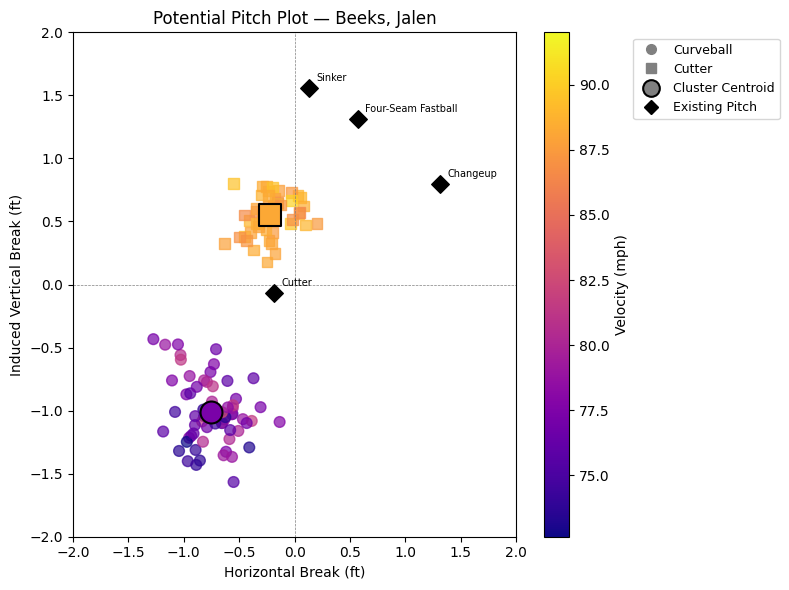

In [33]:
plot_pitch_clusters(j_beeks)

In [30]:
pitch_type_summ[['pfx_x', 'pfx_z']].describe()

,pfx_x,pfx_z
count,21438.000000,21438.000000
mean,-0.122293,0.470297
std,0.890742,0.693741
min,-1.985610,-1.728750
25%,-0.940815,0.069822
50%,-0.165520,0.511144
75%,0.610130,1.013434
max,2.380000,2.260000


In [31]:
pitch_type_summ[abs(pitch_type_summ['pfx_x']) > 2]

,pitch_type,pitcher,player_name,p_throws,game_year,release_speed,release_pos_x,release_pos_z,pfx_x,pfx_z,release_spin_rate,release_extension,release_pos_y,spin_axis,arm_angle,n
20864,ST,672456,"Montero, Keider",R,2025,83.7,-2.59,5.73,2.38,-0.23,2841.0,6.1,54.43,70.0,38.3,1
